## CSI 4142 Assignment 4

Lucas Gavura, 300310069

Jonathan Cojita, 300283917

April 7, 2026

### Work Split:

Lucas Gavura: Part 1, studies 1 and 3

Jonathan Cojita: Part 2, 

### Database summary:

#### Database 1: The Movies Dataset 

metadata.csv: 24 Columns 45000 Rows

### Database 2: 

Columns

Rows

## Movies Dataset - Data Preparation


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
import kagglehub
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

print('Libraries imported successfully.')

Libraries imported successfully.


In [42]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "rounakbanik/the-movies-dataset"
)

df_raw = pd.read_csv(f"{path}/movies_metadata.csv")

#Preview the dataset and info about the columns and data types
print(df_raw.head())
print(df_raw.info())

   adult                                        belongs_to_collection  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', 'poster_pa...   
1  False                                                          NaN   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collection', 'pos...   
3  False                                                          NaN   
4  False  {'id': 96871, 'name': 'Father of the Bride Collection', ...   

     budget                                                       genres  \
0  30000000  [{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Co...   
1  65000000  [{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fa...   
2         0  [{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'C...   
3  16000000  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama...   
4         0                               [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney

In [43]:
# Data types and non-null counts 
print('Data Types & Non-Null Counts')
df_raw.info()

Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45

In [44]:
# Missing value analysis 
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('=== Missing Values ===')
print(missing_df)

=== Missing Values ===
                       Missing Count  Missing %
belongs_to_collection          40972      90.12
homepage                       37684      82.88
tagline                        25054      55.10
overview                         954       2.10
poster_path                      386       0.85
runtime                          263       0.58
status                            87       0.19
release_date                      87       0.19
imdb_id                           17       0.04
original_language                 11       0.02
spoken_languages                   6       0.01
title                              6       0.01
video                              6       0.01
vote_average                       6       0.01
revenue                            6       0.01
vote_count                         6       0.01
popularity                         5       0.01
production_companies               3       0.01
production_countries               3       0.01


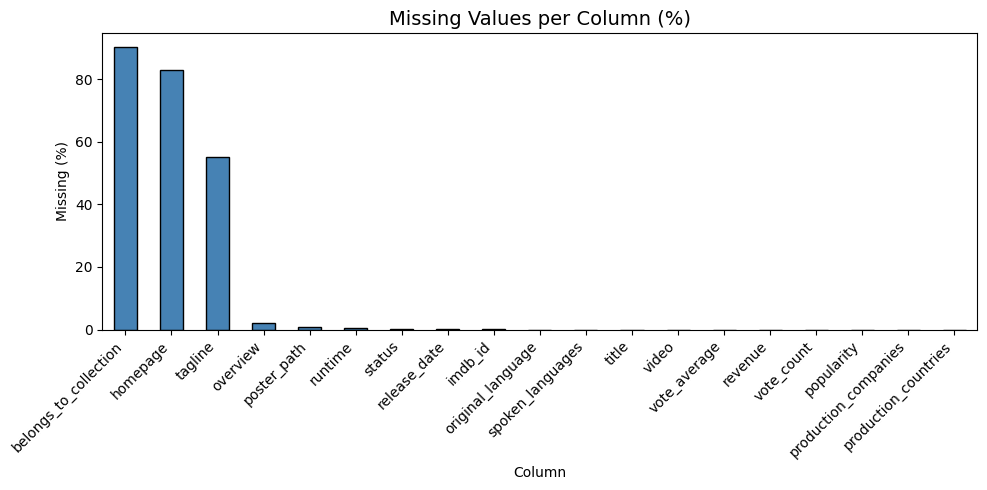

In [45]:
# Visualisation of the missing values bar chart
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Missing Values per Column (%)', fontsize=14)
ax.set_ylabel('Missing (%)')
ax.set_xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [46]:
df = df_raw.copy()

# Convert to numeric
for col in ['budget', 'revenue', 'runtime']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['vote_average', 'vote_count', 'popularity']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse genres from JSON to list
def parse_genres(val):
    try:
        parsed = ast.literal_eval(val)
        return [g['name'] for g in parsed if isinstance(g, dict) and 'name' in g]
    except:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)
df['genres_str'] = df['genres_list'].apply(lambda x: ' '.join(x) if x else '')

# Drop rows
df = df.dropna(subset=['title'])
df = df[df['genres_list'].map(len) > 0]

# Replace zeros
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)
df['runtime'] = df['runtime'].replace(0, np.nan)

# Drop rows missing runtime
df = df.dropna(subset=['runtime'])

# Keep movies with meaningful vote amt
df = df[df['vote_count'] >= 10]

df = df.reset_index(drop=True)
print(f'Cleaned dataset shape: {df.shape}')
df[['title', 'genres_list', 'budget', 'revenue', 'runtime', 'vote_average', 'popularity']].head(5)

Cleaned dataset shape: (22578, 26)


,title,genres_list,budget,revenue,runtime,vote_average,popularity
0,Toy Story,"[Animation, Comedy, Family]",30000000.0,373554033.0,81.0,7.7,21.946943
1,Jumanji,"[Adventure, Fantasy, Family]",65000000.0,262797249.0,104.0,6.9,17.015539
2,Grumpier Old Men,"[Romance, Comedy]",NaN,NaN,101.0,6.5,11.712900
3,Waiting to Exhale,"[Comedy, Drama, Romance]",16000000.0,81452156.0,127.0,6.1,3.859495
4,Father of the Bride Part II,[Comedy],NaN,76578911.0,106.0,5.7,8.387519


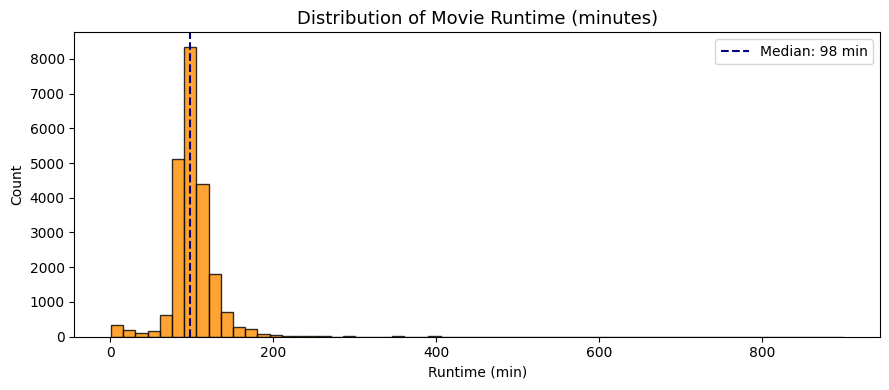

In [47]:
# Visualisation of Runtime distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['runtime'].dropna(), bins=60, color='darkorange', edgecolor='black', alpha=0.8)
ax.set_title('Distribution of Movie Runtime (minutes)', fontsize=13)
ax.set_xlabel('Runtime (min)')
ax.set_ylabel('Count')
ax.axvline(df['runtime'].median(), color='navy', linestyle='--', label=f'Median: {df["runtime"].median():.0f} min')
ax.legend()
plt.tight_layout()
plt.show()

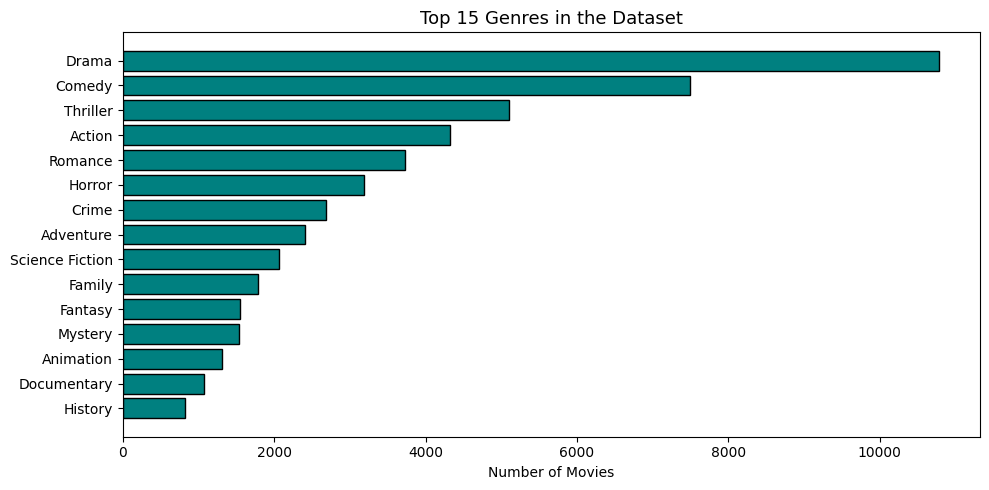

In [48]:
# Visualisation of genres
from collections import Counter

all_genres = [g for sublist in df['genres_list'] for g in sublist]
genre_counts = Counter(all_genres).most_common(15)
genres_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(genres_df['Genre'][::-1], genres_df['Count'][::-1], color='teal', edgecolor='black')
ax.set_title('Top 15 Genres in the Dataset', fontsize=13)
ax.set_xlabel('Number of Movies')
plt.tight_layout()
plt.show()

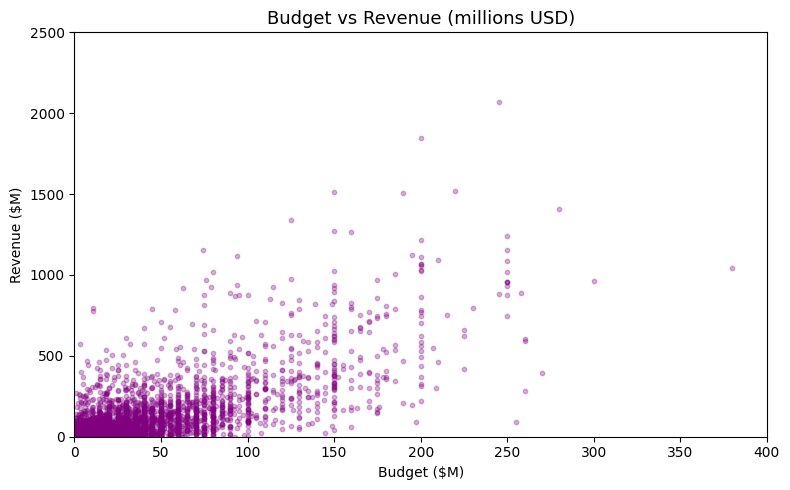

Movies with both budget and revenue data: 4925


In [49]:
# Visualisation of Budget vs Revenue
df_br = df.dropna(subset=['budget', 'revenue'])
df_br = df_br[(df_br['budget'] > 1e5) & (df_br['revenue'] > 1e5)]  # remove extreme near-zeros

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_br['budget'] / 1e6, df_br['revenue'] / 1e6,
           alpha=0.3, s=10, color='purple')
ax.set_title('Budget vs Revenue (millions USD)', fontsize=13)
ax.set_xlabel('Budget ($M)')
ax.set_ylabel('Revenue ($M)')
ax.set_xlim(0, 400)
ax.set_ylim(0, 2500)
plt.tight_layout()
plt.show()

print(f'Movies with both budget and revenue data: {len(df_br)}')

In [50]:
# Normalize numerical our columns
scaler = MinMaxScaler()

for col in ['budget', 'revenue', 'runtime', 'popularity', 'vote_average']:
    df[col + '_filled'] = df[col].fillna(df[col].median())

num_cols = ['budget_filled', 'revenue_filled', 'runtime_filled', 'popularity_filled', 'vote_average_filled']
df[num_cols] = scaler.fit_transform(df[num_cols])

print('Normalized numerical columns:')
df[num_cols].describe().round(3)

Normalized numerical columns:


,budget_filled,revenue_filled,runtime_filled,popularity_filled,vote_average_filled
count,22578.000,22578.000,22578.000,22578.000,22578.000
mean,0.043,0.013,0.112,0.010,0.650
std,0.057,0.031,0.035,0.014,0.105
min,0.000,0.000,0.000,0.000,0.000
25%,0.032,0.007,0.099,0.003,0.589
50%,0.032,0.007,0.108,0.007,0.663
75%,0.032,0.007,0.122,0.013,0.726
max,1.000,1.000,1.000,1.000,1.000


## Study 1 - Similarity Measures

In [51]:
#helper function to help retrieve movies
def find_movie(title_query, df):
    #Find a movie by title return error if not found
    mask = df['title'].str.contains(title_query, case=False, na=False)
    matches = df[mask]
    if len(matches) == 0:
        raise ValueError(f'No movie found matching: "{title_query}"')
    # Tiebreaker if identical
    return matches.sort_values('vote_count', ascending=False).iloc[0]

# Testing
for title in ['Toy Story', 'Titanic', 'The Matrix']:
    m = find_movie(title, df)
    print(f'{title!r:20s} | found: "{m["title"]}" ({m["genres_str"]})')

'Toy Story'          | found: "Toy Story" (Animation Comedy Family)
'Titanic'            | found: "Titanic" (Drama Romance Thriller)
'The Matrix'         | found: "The Matrix" (Action Science Fiction)


### Similarity Measure 1 - Jaccard

In [52]:
# Compute Jaccard similarity between two sets.
def jaccard_similarity(set_a, set_b):
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return 1.0  # edge case if both are empty
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union

# Find the top-N movies most similar in genre to the query
def top_by_genre(query_title, df, n=10):

    query_movie = find_movie(query_title, df)
    query_genres = query_movie['genres_list']
    query_id = query_movie.name  # index

    df_other = df[df.index != query_id].copy()
    df_other['jaccard_score'] = df_other['genres_list'].apply(
        lambda g: jaccard_similarity(query_genres, g)
    )

    top = (
        df_other.sort_values(['jaccard_score', 'popularity_filled'], ascending=[False, False])
        .head(n)[['title', 'genres_str', 'runtime', 'popularity_filled', 'jaccard_score']]
    )
    top.columns = ['Title', 'Genres', 'Runtime (min)', 'Popularity (norm)', 'Jaccard Score']
    return query_movie['title'], query_genres, top


# Finding top 10
qname, qgenres, result1 = top_by_genre('Despicable Me', df)
print(f'Query: "{qname}" | Genres: {qgenres}')
print(f'\nTop 10 movies with most similar genre:')
result1

Query: "Despicable Me" | Genres: ['Animation', 'Family']

Top 10 movies with most similar genre:


,Title,Genres,Runtime (min),Popularity (norm),Jaccard Score
4940,Finding Nemo,Animation Family,100.0,0.046572,1.0
4246,Lilo & Stitch,Animation Family,85.0,0.033734,1.0
1524,The Little Mermaid,Animation Family,83.0,0.031958,1.0
10268,Coraline,Animation Family,100.0,0.030393,1.0
14139,Monsters University,Animation Family,104.0,0.029713,1.0
7821,Madagascar,Family Animation,86.0,0.029473,1.0
9832,WALL·E,Animation Family,98.0,0.029385,1.0
11808,Tangled,Animation Family,100.0,0.026822,1.0
755,Dumbo,Animation Family,64.0,0.026769,1.0
482,Pinocchio,Animation Family,88.0,0.025940,1.0


### Similarity Measure 2 - Euclidean Distance

In [53]:
# Compute Euclidean similarity
def euclidean_similarity(val_a, val_b):
    dist = abs(val_a - val_b)  # = sqrt((a-b)^2)
    return 1 / (1 + dist)

# Find the top-N movies most similar in revenue to the query
def top_by_revenue(query_title, df, n=10):
    query_movie = find_movie(query_title, df)
    query_val = query_movie['revenue_filled']
    query_id = query_movie.name

    # Filtering movies with revenue data
    df_rev = df[(df.index != query_id) & (df['revenue'].notna())].copy()
    df_rev['euclidean_sim'] = df_rev['revenue_filled'].apply(
        lambda v: euclidean_similarity(query_val, v)
    )

    top = (
        df_rev.sort_values('euclidean_sim', ascending=False)
        .head(n)[['title', 'genres_str', 'revenue', 'euclidean_sim']]
    )
    top = top.copy()
    top['revenue'] = top['revenue'].apply(lambda x: f'${x/1e6:.1f}M')
    top.columns = ['Title', 'Genres', 'Revenue', 'Euclidean Sim']
    return query_movie['title'], query_movie['revenue'], top


# Finding top 10
qname, qrev, result2 = top_by_revenue('Titanic', df)
print(f'Query: "{qname}" | Revenue: ${qrev/1e6:.1f}M')
print(f'\nTop 10 movies with most similar revenue:')
result2

Query: "Titanic" | Revenue: $1845.0M

Top 10 movies with most similar revenue:


,Title,Genres,Revenue,Euclidean Sim
16580,Star Wars: The Force Awakens,Action Adventure Science Fiction Fantasy,$2068.2M,0.925879
12564,The Avengers,Science Fiction Action Adventure,$1519.6M,0.895461
15993,Jurassic World,Action Adventure Science Fiction Thriller,$1513.5M,0.893730
17193,Furious 7,Action,$1506.2M,0.891650
16583,Avengers: Age of Ultron,Action Adventure Science Fiction,$1405.4M,0.863790
12387,Harry Potter and the Deathly Hallows: Part 2,Family Fantasy Adventure,$1342.0M,0.847148
14630,Frozen,Animation Adventure Family,$1274.2M,0.830053
21587,Beauty and the Beast,Family Fantasy Romance,$1262.9M,0.827262
21924,The Fate of the Furious,Action Crime Thriller,$1238.8M,0.821383
14021,Iron Man 3,Action Adventure Science Fiction,$1215.4M,0.815777


### Similarity Measure 3 - Manhattan Distance

In [54]:
# Compute Manhattan similarity
def manhattan_similarity(val_a, val_b):
    dist = abs(val_a - val_b)
    return 1 / (1 + dist)

# Find the top-N movies most similar in runtime to the query
def top_by_runtime(query_title, df, n=10):

    query_movie = find_movie(query_title, df)
    query_val = query_movie['runtime_filled']
    query_runtime = query_movie['runtime']
    query_id = query_movie.name

    df_rt = df[df.index != query_id].copy()
    df_rt['manhattan_sim'] = df_rt['runtime_filled'].apply(
        lambda v: manhattan_similarity(query_val, v)
    )

    top = (
        df_rt.sort_values('manhattan_sim', ascending=False)
        .head(n)[['title', 'genres_str', 'runtime', 'manhattan_sim']]
    )
    top.columns = ['Title', 'Genres', 'Runtime (min)', 'Manhattan Sim']
    return query_movie['title'], query_runtime, top


# Finding the top 10
qname, qrt, result3 = top_by_runtime('Frozen', df)
print(f'Query: "{qname}" | Runtime: {qrt:.0f} min')
print(f'\nTop 10 movies with most similar runtime:')
result3

Query: "Frozen" | Runtime: 102 min

Top 10 movies with most similar runtime:


,Title,Genres,Runtime (min),Manhattan Sim
13335,Samsara,Drama Documentary,102.0,1.0
9442,Be Kind Rewind,Drama Comedy,102.0,1.0
3112,House of Games,Crime Drama Mystery Thriller,102.0,1.0
3105,State and Main,Comedy Drama,102.0,1.0
20834,Cal,Drama Thriller Romance,102.0,1.0
15156,Rio 2,Animation Adventure Comedy Family,102.0,1.0
8463,The President's Last Bang,Comedy,102.0,1.0
5909,The Left Handed Gun,Drama Action Western,102.0,1.0
11249,Downloading Nancy,Drama Thriller,102.0,1.0
4007,The Bad News Bears,Comedy Family,102.0,1.0


### Similarity Measure 4 - Edit Disance

In [55]:
# finding the Levenshtein Edit Distance between two strings.
def edit_distance(s1, s2):
    s1 = s1.lower().strip()
    s2 = s2.lower().strip()
    m, n = len(s1), len(s2)

    # dp[i][j] = edit distance between s1[:i] and s2[:j]
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Base cases
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    # Fill the DP table
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] # if char match
            else:
                dp[i][j] = 1 + min(
                    dp[i - 1][j], # deletion
                    dp[i][j - 1], # insertion
                    dp[i - 1][j - 1] # substitution
                )
    return dp[m][n]

# Normalizing distance
def edit_similarity(s1, s2):
    max_len = max(len(s1), len(s2))
    if max_len == 0:
        return 1.0
    return 1.0 - edit_distance(s1, s2) / max_len

# Find the top-N movies most similar in title to the query
def top_by_title_edit(query_title, df, n=10):

    query_movie = find_movie(query_title, df)
    query_id = query_movie.name
    q_title = query_movie['title']

    df_other = df[df.index != query_id].copy()
    df_other['edit_sim'] = df_other['title'].apply(
        lambda t: edit_similarity(q_title, str(t))
    )

    top = (
        df_other.sort_values(['edit_sim', 'popularity_filled'], ascending=[False, False])
        .head(n)[['title', 'genres_str', 'runtime', 'vote_average', 'edit_sim']]
    )
    top.columns = ['Title', 'Genres', 'Runtime (min)', 'Vote Avg', 'Edit Similarity']
    return query_movie['title'], top


# Finding the top 10
qname, result4 = top_by_title_edit('Star Wars: The Clone Wars', df)
print(f'\nQuery: "{qname}"')
print(f'\nTop 10 movies with most similar title (Edit Distance):')
result4


Query: "Star Wars: The Clone Wars"

Top 10 movies with most similar title (Edit Distance):


,Title,Genres,Runtime (min),Vote Avg,Edit Similarity
16580,Star Wars: The Force Awakens,Action Adventure Science Fiction Fantasy,136.0,7.5,0.714286
19662,Garm Wars: The Last Druid,Action Science Fiction Thriller,92.0,4.1,0.520000
3208,Series 7: The Contenders,Action Comedy Thriller,86.0,6.3,0.520000
10110,Farscape: The Peacekeeper Wars,Action Comedy Romance Science Fiction Thriller,182.0,7.5,0.500000
1022,Star Trek: The Motion Picture,Science Fiction Adventure Mystery,132.0,6.2,0.482759
8901,Code Name: The Cleaner,Action Comedy Crime,84.0,4.7,0.480000
3640,The War of the Roses,Comedy Drama Thriller,116.0,6.7,0.480000
8118,Tarzan the Ape Man,Action Adventure,100.0,6.5,0.480000
2702,Shakes the Clown,Action Comedy,87.0,5.5,0.480000
4559,"Tarzan, the Ape Man",Adventure Action Comedy,107.0,3.8,0.480000


### Similarity Measure 5 - Euclidean Distance in 2d

In [56]:
# Compute Euclidean distance between two arrays
def euclidean_distance_2d(vec_a, vec_b):
    dist = np.sqrt(np.sum((vec_a - vec_b) ** 2))
    return 1 / (1 + dist)

# Find the top-N movies most similar in budget and vote_average to the query
def top_by_budget_rating(query_title, df, n=10):

    query_movie = find_movie(query_title, df)
    query_vec = np.array([
        query_movie['budget_filled'],
        query_movie['vote_average_filled']
    ])
    query_id = query_movie.name

    df_bud = df[(df.index != query_id) & (df['budget'].notna())].copy()
    df_bud['euclid_sim'] = df_bud.apply(
        lambda row: euclidean_distance_2d(
            query_vec,
            np.array([row['budget_filled'], row['vote_average_filled']])
        ), axis=1
    )

    top = (
        df_bud.sort_values('euclid_sim', ascending=False)
        .head(n)[['title', 'genres_str', 'budget', 'vote_average', 'euclid_sim']]
    )
    top = top.copy()
    top['budget'] = top['budget'].apply(lambda x: f'${x/1e6:.1f}M')
    top.columns = ['Title', 'Genres', 'Budget', 'Vote Avg', 'Euclidean Sim']
    return query_movie['title'], top


# Finding the top 10
qname, result5 = top_by_budget_rating('The Matrix', df)
print(f'Query: "{qname}"')
print(f'\nTop 10 movies with most similar budget + rating profile:')
result5

Query: "The Matrix"

Top 10 movies with most similar budget + rating profile:


,Title,Genres,Budget,Vote Avg,Euclidean Sim
15362,Gone Girl,Mystery Thriller Drama,$61.0M,7.9,0.994764
1229,The Truman Show,Comedy Drama,$60.0M,7.8,0.987013
1477,Saving Private Ryan,Drama History War,$70.0M,7.9,0.981912
10328,Everlasting Moments,Drama,$70.0M,7.9,0.981912
10414,Inglourious Basterds,Drama Action Thriller War,$70.0M,7.9,0.981912
5,Heat,Action Crime Drama Thriller,$60.0M,7.7,0.978010
20865,Kubo and the Two Strings,Animation Adventure Family,$60.0M,7.7,0.978010
3888,A Beautiful Mind,Drama Romance,$60.0M,7.7,0.978010
8616,The Pursuit of Happyness,Drama,$55.0M,7.7,0.971088
15,Casino,Drama Crime,$52.0M,7.8,0.970119


## Study 2 - Clustering Algorithms

The purpose of this study is to test 2 different clustering algorithms. We saw KMeans and DBSCAN in
class. You are required to test those two algorithms.

For each clustering algorithm, try at least a few variations on the hyper-parameters. For KMeans,
test at least 2 values for k(1), and for DBSCAN, test at least 2 values for eps and min_samples.

Clustering is based on similarity. You are asked to combine at 2 attributes (from Study 1) for the
similarities you use for clustering. Try at least 2 different combinations of 2 attributes. Limiting the
similarity to be on 2 attributes will make it easier to do visual inspection on the resulting clusters.

Show your visual inspection results(2) for your combinations of attributes. For example, for the
movie dataset, I can cluster and visualize results on (Revenue versus Budget) and (Runtime versus
Budget), and that for each of the clustering algorithm.

Discuss which clustering algorithm (KMeans versus DBSCAN) seems more appropriate based on your
visual inspection. Beyond visual inspection, you can also explore the cluster metrics we discussed in
class (Cluster magnitude and cardinality), but that is optional.

Notes:
(1) You can also try to find the best value for K using the method shown during the lecture (trying
k from small to large and measuring the cumulated magnitude over all clusters). That is
optional.
(2) There is a lot of code online to perform cluster visualization in Python, such as shown in the
Demo of DBSCAN clustering algorithm (link) in sklearn.

## Study 3 – Content-Based Recommendation System

## Study 4 -  Collaborative Filtering Recommendation System

In [57]:
#Load in ratings.csv
ratings_path = f"{path}/ratings.csv"
ratings = pd.read_csv(ratings_path)
print('Ratings dataset loaded successfully.')
print(ratings.head())

Ratings dataset loaded successfully.
   userId  movieId  rating   timestamp
0       1      110     1.0  1425941529
1       1      147     4.5  1425942435
2       1      858     5.0  1425941523
3       1     1221     5.0  1425941546
4       1     1246     5.0  1425941556


In [58]:
#Build Utility Matrix, where rows are users, columns are movies, and values are ratings
#Take a random sample of users (Too large to build utility matrix on full dataset)
sampled_users = ratings['userId'].drop_duplicates().sample(n=10000, random_state=42)
ratings_sampled = ratings[ratings['userId'].isin(sampled_users)]

#Build utility matrix on the sample
utility_matrix = ratings_sampled.pivot_table(index='userId', columns='movieId', values='rating')
print(utility_matrix.shape)


(10000, 19593)


In [59]:
#Using suprise library instead of reccomended numpy implementation for matrix factorization to save time and memory
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings_sampled[['userId', 'movieId', 'rating']], reader)

#Reserve 10% for the 'Gold Standard'
trainset, testset = train_test_split(data, test_size=0.1, random_state=42)

#Train SVD with multiple latent dimension values
n_factors_list = [10, 20, 50, 100]
all_predictions = {}

for n in n_factors_list:
    model = SVD(n_factors=n)
    model.fit(trainset)
    all_predictions[n] = model.test(testset)


In [60]:
from surprise import accuracy
import numpy as np
from collections import defaultdict

RELEVANT_THRESHOLD = 4.0

def precision_at_k(user_preds, k):
    precisions = []
    for uid, preds in user_preds.items():
        top_k = preds[:k]
        relevant = sum(1 for _, actual in top_k if actual >= RELEVANT_THRESHOLD)
        precisions.append(relevant / k)
    return np.mean(precisions)

def mean_reciprocal_rank(user_preds):
    reciprocal_ranks = []
    for uid, preds in user_preds.items():
        reciprocal_rank = 0.0
        for rank, (predicted_score, actual_score) in enumerate(preds, start=1):
            if actual_score >= RELEVANT_THRESHOLD:
                reciprocal_rank = 1.0 / rank
                break
        reciprocal_ranks.append(reciprocal_rank)
    return np.mean(reciprocal_ranks)

for n, predictions in all_predictions.items():
    print(f'n_factors={n}')

    print(' Evaluation 1: MSE/RMSE')
    print('     RMSE:', accuracy.rmse(predictions, verbose=False))
    print('     MSE:', accuracy.mse(predictions, verbose=False))

    print(' Evaluation 2: Binary Relevance')
    user_predictions = defaultdict(list)
    for p in predictions:
        user_predictions[p.uid].append((p.est, p.r_ui))
    for uid in user_predictions:
        user_predictions[uid].sort(key=lambda x: x[0], reverse=True)

    print('     P@5: ', precision_at_k(user_predictions, 5))
    print('     P@10:', precision_at_k(user_predictions, 10))
    print('     MRR: ', mean_reciprocal_rank(user_predictions))
    print()


n_factors=10
 Evaluation 1: MSE/RMSE
     RMSE: 0.8400637875853239
     MSE: 0.7057071672122002
 Evaluation 2: Binary Relevance
     P@5:  0.45881246325690767
     P@10: 0.33192239858906525
     MRR:  0.764158020310141

n_factors=20
 Evaluation 1: MSE/RMSE
     RMSE: 0.8340239936490571
     MSE: 0.6955960219823224
 Evaluation 2: Binary Relevance
     P@5:  0.46130511463844803
     P@10: 0.3329218106995885
     MRR:  0.7668393769011053

n_factors=50
 Evaluation 1: MSE/RMSE
     RMSE: 0.8329273266120985
     MSE: 0.6937679314171774
 Evaluation 2: Binary Relevance
     P@5:  0.460952380952381
     P@10: 0.3329688418577308
     MRR:  0.766735591355884

n_factors=100
 Evaluation 1: MSE/RMSE
     RMSE: 0.8340984604680826
     MSE: 0.6957202417552255
 Evaluation 2: Binary Relevance
     P@5:  0.4610934744268078
     P@10: 0.33394473838918287
     MRR:  0.7641558990737493



### Results and Anaylsis:
The reccomended code for Matrix Factorization performed inhibitingly slow. Instead we use the Scikit-suprise library to perform the same task, acheiving a much faster compute time. As we increase the latent dimension count (n-factors), we notice a steady, but small decrease in the RMSE and MSE, showing improvement but smaller returns. Overall, the RMSE is not incredibly impressive, showing an error of ~0.83-0.84 stars, large for such a small range (0.5 - 5), yet we have a contrastingly decent MRR of ~0.76. This shows that while the model struggles when predicting how a user will specifically rate a movie, it does a good job at reccomending movies which are at least relevant to them. In terms of P@k metrics, the model is most accurate with the top movies it reccomends, and drops as the list continues (observable with the drop from P@5 to P@10 accross all latent dimension experiments).